In [ ]:
from google.colab import drive
try:
  import awkward as ak
except:
  !pip install awkward
  import awkward as ak
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.patches import RegularPolygon
import plotly.graph_objects as go

drive.mount('/content/drive')

parquet_path = "/content/drive/MyDrive/parquet_chunks/chunk_500000.parquet"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 43.3 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
events = ak.from_parquet(parquet_path)

print(f"Dataset caricato")
print(f"Numero totale di eventi: {len(events)}")
print(f"Variabili: {events.fields}")

Dataset caricato
Numero totale di eventi: 100000
Variabili: ['energy', 'x', 'y', 'z', 'target']


In [ ]:
target_ene = ak.to_numpy(events.target[:, 0])
print(target_ene.shape)

(100000,)


In [ ]:
#np.save("/content/drive/MyDrive/target_energy5", target_ene)

In [ ]:
event_idx = 61240
print(f"Event {event_idx} info:")
print(f"Number of hits: {len(events[event_idx].x)}")
print(f"Hit x: {events[event_idx].x}")
print(f"Hit y: {events[event_idx].y}")
print(f"Hit z: {events[event_idx].z}")
print(f"Hit energy: {events[event_idx].energy}")
print(f"Target energy: {events[event_idx].target}")

Evento 61240 info:
Numero di hit: 1361
Hit x: [0, -0.972, -0.972, -0.972, -0.972, ..., -1.94, -1.94, -1.94, -2.92, -2.92]
Hit y: [3.37, -0.561, 3.93, 1.68, 0.561, 4.49, ..., 4.49, 2.24, 1.12, 0, -1.68, 1.68]
Hit z: [13.9, 13.9, 13.9, 13.9, 13.9, 13.9, ..., 53.9, 53.9, 53.9, 53.9, 53.9, 53.9]
Hit energy: [0.573, 3.21, 1.18, 4.93, 38.1, 10.1, ..., 1.27, 1.38, 1.96, 3.65, 1.53, 3.74]
Target energy: [344, 344, 344, 344, 344, 344, 344, 344, ..., 344, 344, 344, 344, 344, 344, 344]


In [ ]:
total_hits = ak.num(events.energy, axis=1)

print(f"Numero medio di hit: {np.mean(total_hits):.2f}")
print(f"Evento con più hit idx :{np.argmax(total_hits)}, con {np.max(total_hits)} hits")

Numero medio di hit: 798.85
Evento con più hit idx :61240, con 1361 hits


In [ ]:
x_hits = events[event_idx].x
y_hits = events[event_idx].y
z_hits = events[event_idx].z
energy_hits = events[event_idx].energy
target_hits = events[event_idx].target

In [ ]:
x_pos = np.unique(ak.flatten(events.x))
y_pos = np.unique(ak.flatten(events.y))
dx = np.diff(x_pos)[0]
dy = np.diff(y_pos)[0]
print(f"delta x: {dx}, delta y: {dy}")


delta x: 0.9717636108398438, delta y: 0.5610480308532715


In [ ]:
zlayers_coordinate = np.unique(ak.flatten(events.z))
print(f"Z layers coordinate in cm: {zlayers_coordinate}, in totale {len(zlayers_coordinate)} layers")


Z layers coordinate in cm: [13.9, 14.8, 16.8, 17.7, 19.7, 20.6, ..., 46.4, 47.5, 49.7, 50.7, 52.9, 53.9], in totale 28 layers


In [ ]:
density = np.sqrt(dx**2 + dy**2)
print(f"density: {density}")

density: 1.1220959424972534


In [ ]:
xy = ak.zip((x_hits, y_hits))
grid = np.unique(np.asarray(xy))
print(f"griglia: {grid}")

griglia: [(-6.8023453, -0.561048 ) (-6.8023453,  0.561048 )
 (-5.8305817, -1.122096 ) (-5.8305817,  0.       )
 (-5.8305817,  1.122096 ) (-5.8305817,  2.244192 )
 (-4.858818 , -3.9273357) (-4.858818 , -2.80524  )
 (-4.858818 , -1.683144 ) (-4.858818 , -0.561048 )
 (-4.858818 ,  0.561048 ) (-4.858818 ,  1.683144 )
 (-4.858818 ,  2.80524  ) (-4.858818 ,  3.9273357)
 (-3.8870544, -5.61048  ) (-3.8870544, -4.488384 )
 (-3.8870544, -3.366288 ) (-3.8870544, -2.244192 )
 (-3.8870544, -1.122096 ) (-3.8870544,  0.       )
 (-3.8870544,  1.122096 ) (-3.8870544,  2.244192 )
 (-3.8870544,  3.366288 ) (-3.8870544,  4.488384 )
 (-3.8870544,  5.61048  ) (-2.9152908, -6.171528 )
 (-2.9152908, -5.049432 ) (-2.9152908, -3.9273357)
 (-2.9152908, -2.80524  ) (-2.9152908, -1.683144 )
 (-2.9152908, -0.561048 ) (-2.9152908,  0.561048 )
 (-2.9152908,  1.683144 ) (-2.9152908,  2.80524  )
 (-2.9152908,  3.9273357) (-2.9152908,  5.049432 )
 (-2.9152908,  6.171528 ) (-1.9435272, -5.61048  )
 (-1.9435272, -4.48838

In [ ]:
grid_x = np.array(list(map(lambda x: x[0], grid))).astype('float32')
grid_y = np.array(list(map(lambda x: x[1], grid))).astype('float32')
norm_grid_x = grid_x/density
norm_grid_y = grid_y/density

In [ ]:
rndw = np.zeros(grid.shape[0])
for i in range(grid.shape[0]):
    rndw[i] = np.random.rand()

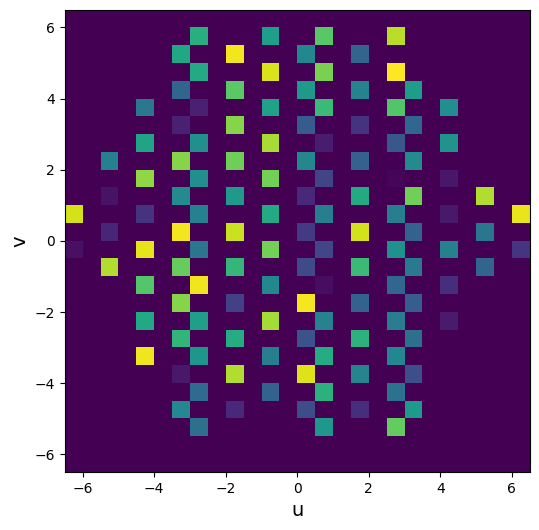

In [ ]:
plt.figure(figsize=(6,6))
plt.hist2d(norm_grid_x, norm_grid_y, weights=rndw, bins=(26,26), range=((-6.5,6.5),(-6.5,6.5)))
plt.xlabel('u', fontsize=14)
plt.ylabel('v', fontsize=14)
plt.show()

In [ ]:
event = events[event_idx]
x_per_layer = []
y_per_layer = []
z_per_layer = []
e_per_layer = []

for z_val in zlayers_coordinate:

    mask = (event.z == z_val)
    x_hits = ak.to_numpy(event.x[mask])
    y_hits = ak.to_numpy(event.y[mask])
    z_hits = ak.to_numpy(event.z[mask])
    e_hits = ak.to_numpy(event.energy[mask])

    x_per_layer.append(x_hits)
    y_per_layer.append(y_hits)
    z_per_layer.append(z_hits)
    e_per_layer.append(e_hits)

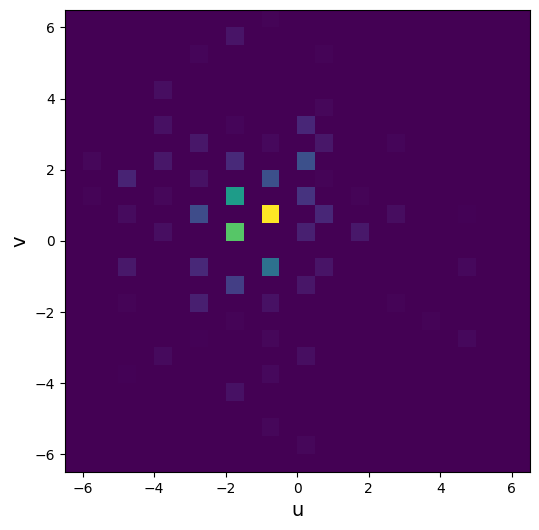

In [ ]:
plt.figure(figsize=(6,6))
plt.hist2d(x_per_layer[18], y_per_layer[18], weights=e_per_layer[18], bins=(26,26), range=((-6.5,6.5),(-6.5,6.5)))
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.title(f"Event {event_idx}Energy deposited ")
plt.show()

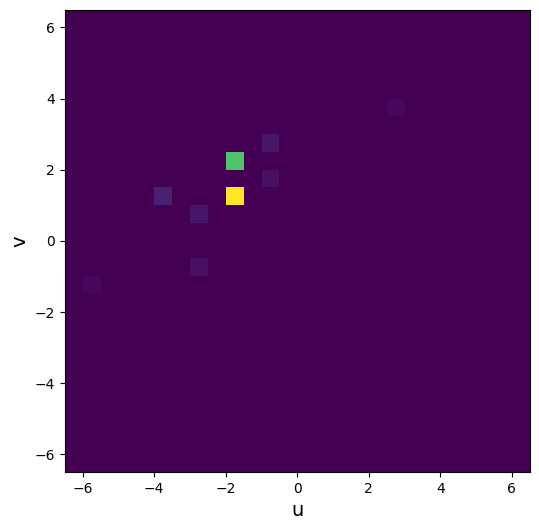

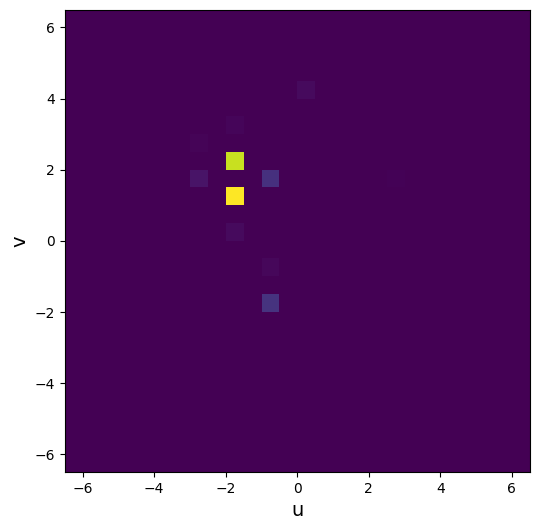

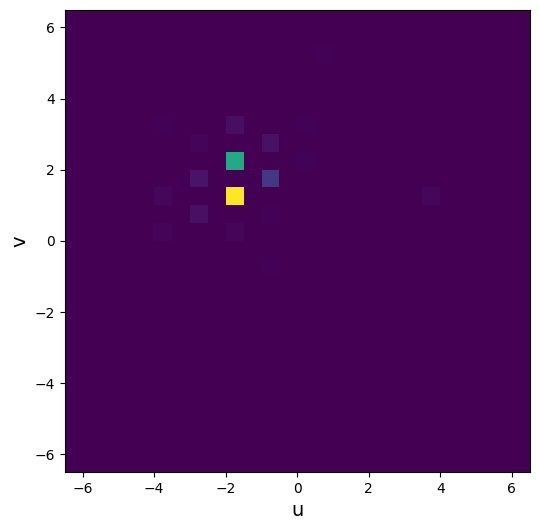

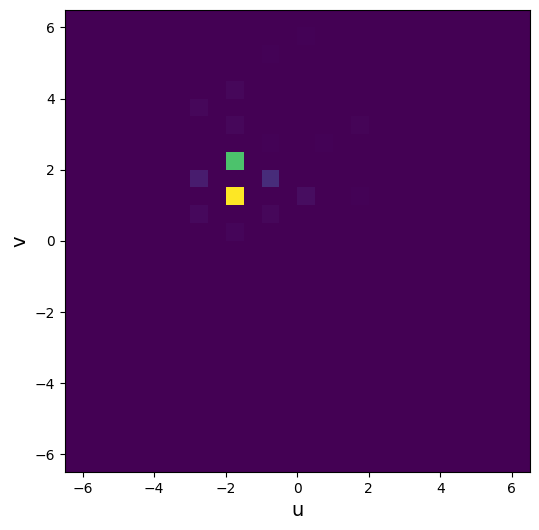

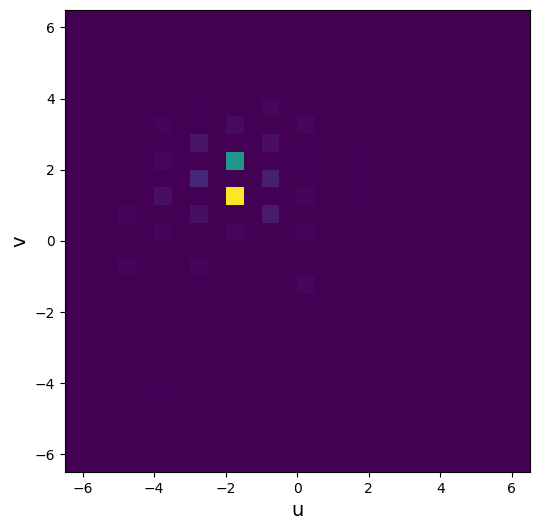

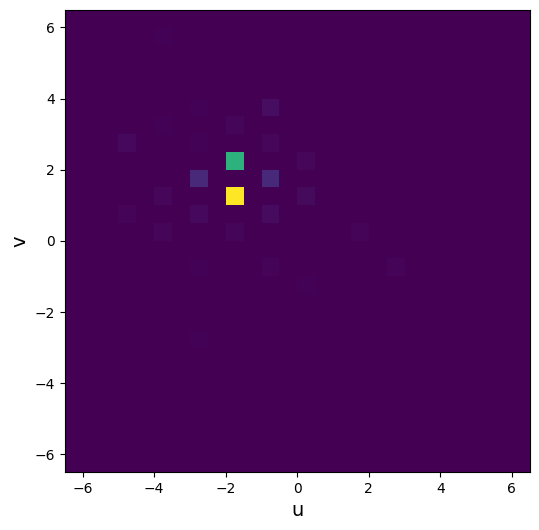

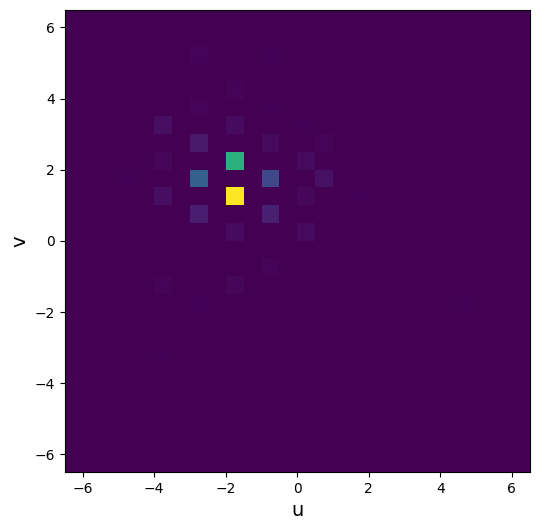

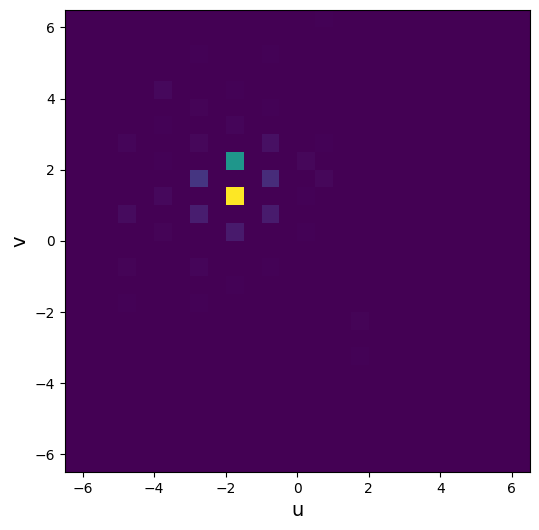

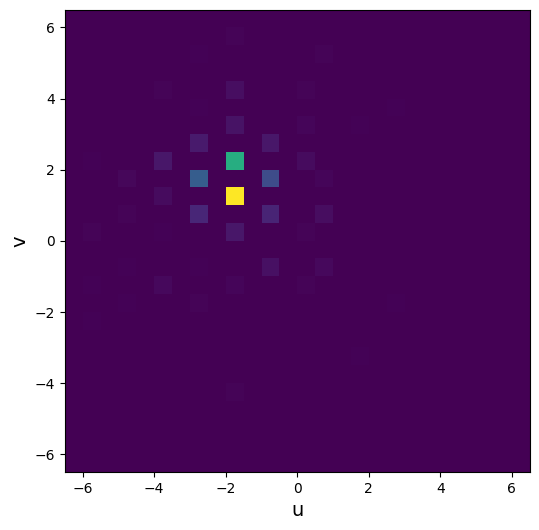

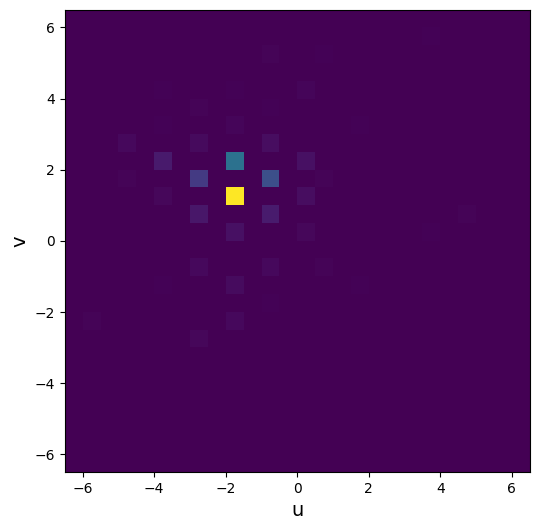

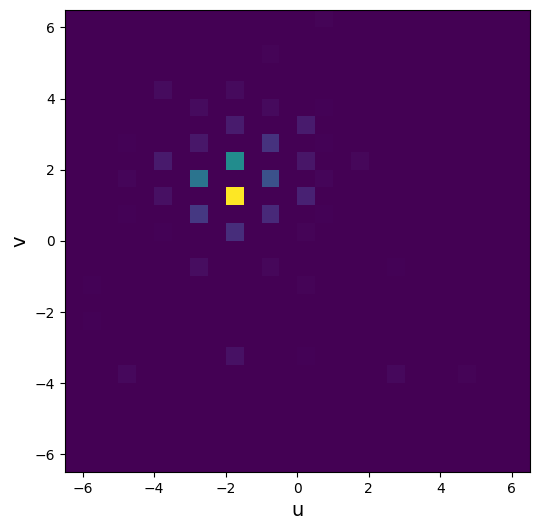

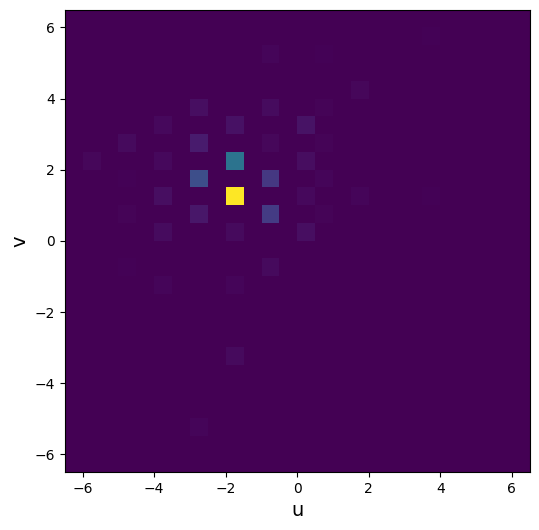

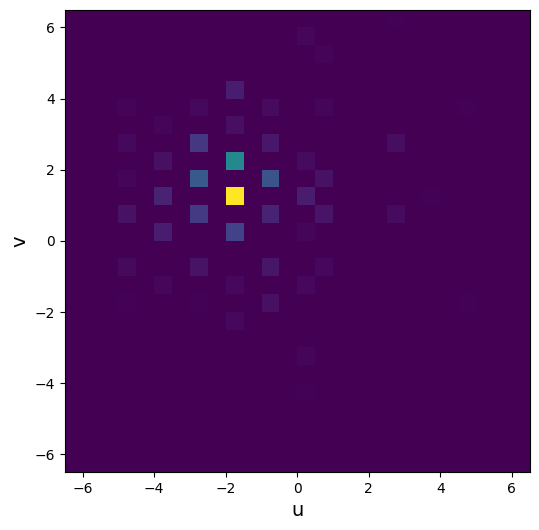

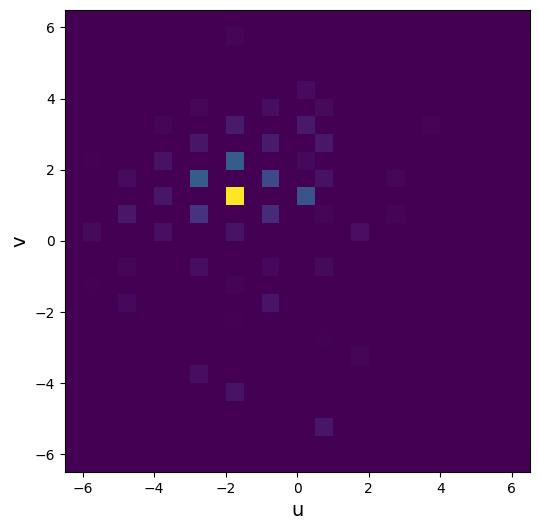

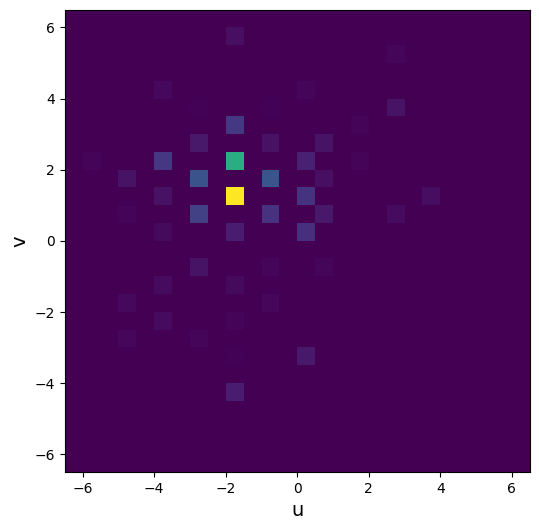

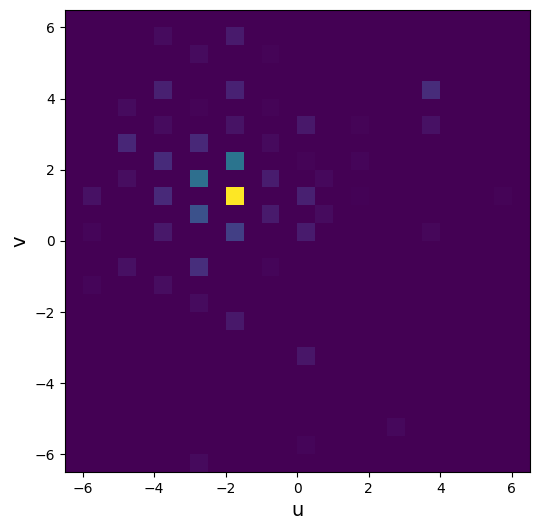

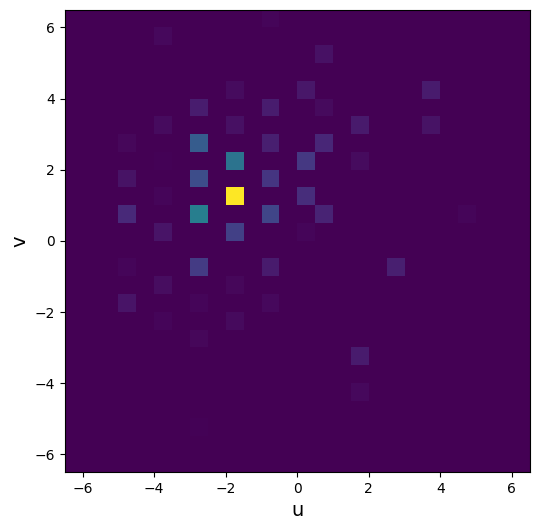

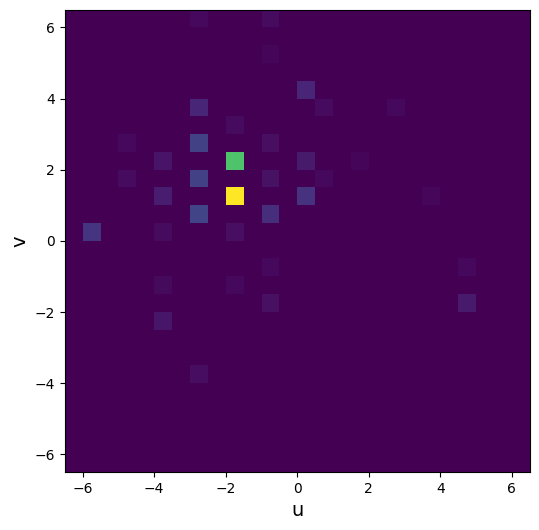

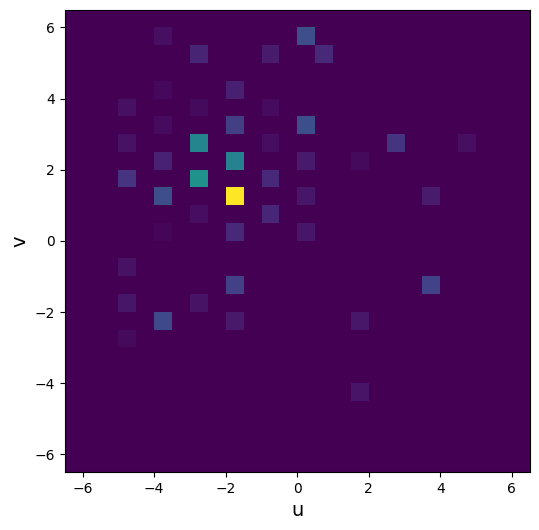

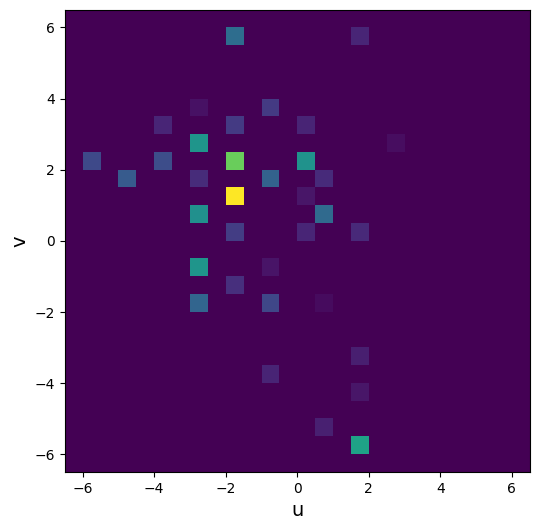

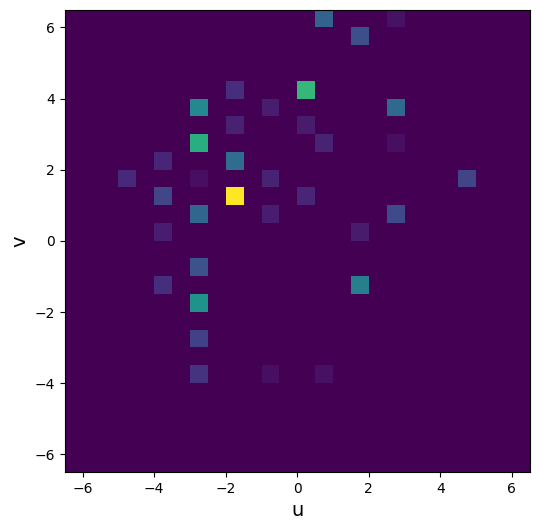

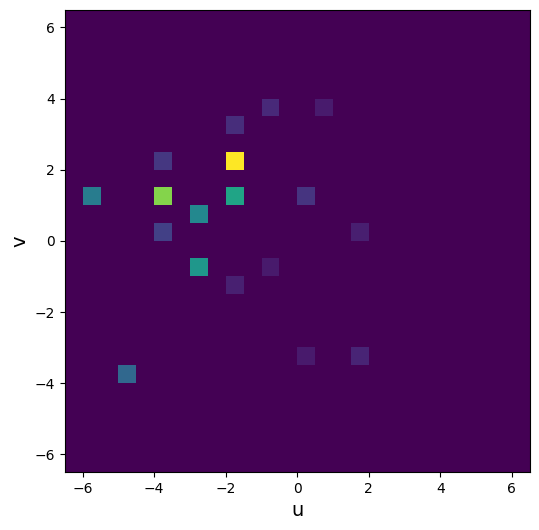

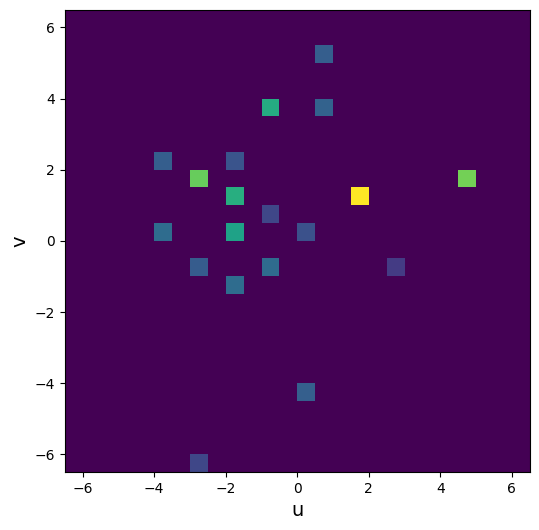

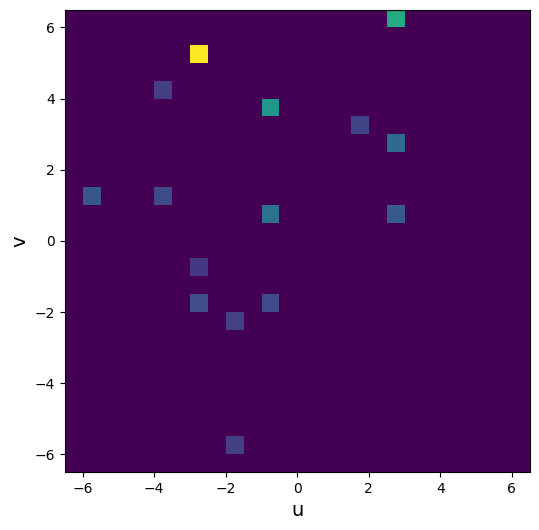

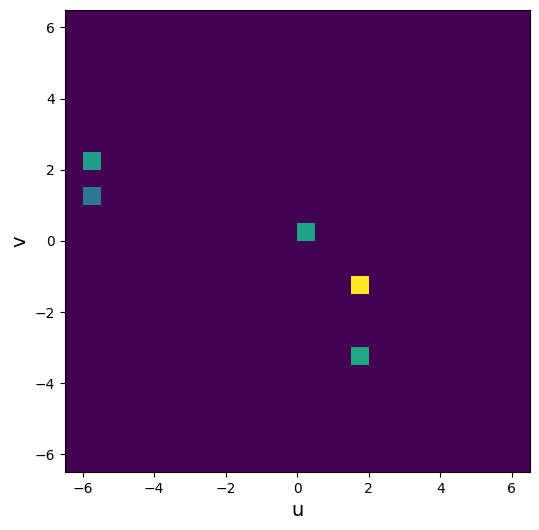

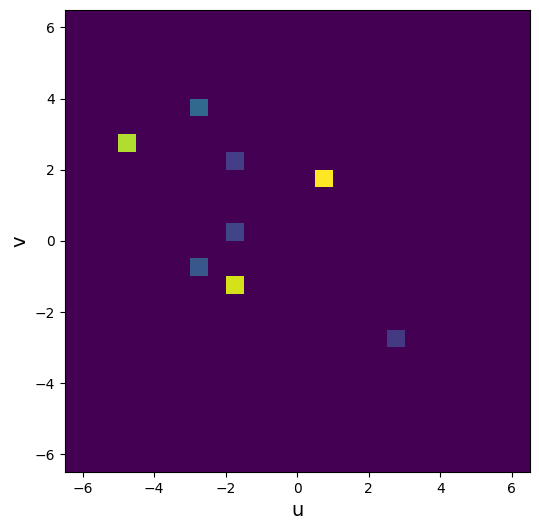

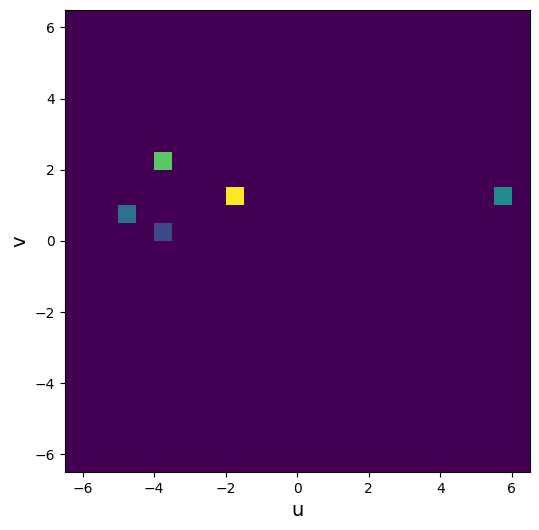

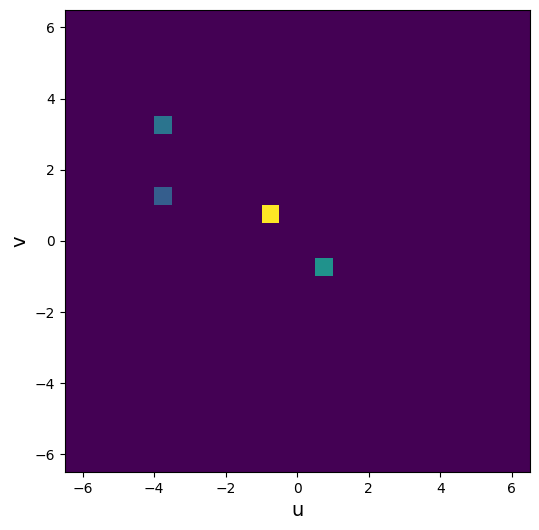

In [ ]:
for i in range(28):
  plt.figure(figsize=(6,6))
  plt.hist2d(x_per_layer[i], y_per_layer[i], weights=e_per_layer[i], bins=(26,26), range=((-6.5,6.5),(-6.5,6.5)))
  plt.xlabel('u', fontsize=14)
  plt.ylabel('v', fontsize=14)
  plt.show()


In [ ]:
import plotly.graph_objects as go

X_flat = np.concatenate(x_per_layer)
Y_flat = np.concatenate(y_per_layer)
E_flat = np.concatenate(e_per_layer)
Z_flat = np.concatenate([np.full_like(x_per_layer[i], zlayers_coordinate[i]) for i in range(len(zlayers_coordinate))])

In [ ]:
#Visualizing 3D with plotly
threshold = 0.1
grid_size = 10  

fig = go.Figure()

for i, z_val in enumerate(zlayers_coordinate):
    x_l, y_l, e_l = x_per_layer[i], y_per_layer[i], e_per_layer[i]
    if len(x_l) == 0: continue
    hist, x_edges, y_edges = np.histogram2d(x_l, y_l, bins=30,
                                            range=[[-grid_size, grid_size], [-grid_size, grid_size]],
                                            weights=e_l)
    hist = hist.T
    X_c, Y_c = np.meshgrid((x_edges[:-1]+x_edges[1:])/2, (y_edges[:-1]+y_edges[1:])/2)

    mask = hist > threshold
    if not np.any(mask): continue
    fig.add_trace(go.Scatter3d(
        x=[z_val]*5, y=[-grid_size, grid_size, grid_size, -grid_size, -grid_size],
        z=[-grid_size, -grid_size, grid_size, grid_size, -grid_size],
        mode='lines', line=dict(color='rgba(150,150,150,0.2)', width=1),
        showlegend=False, hoverinfo='skip'
    ))

 
    fig.add_trace(go.Scatter3d(
        x=np.full(np.sum(mask), z_val),
        y=X_c[mask],
        z=Y_c[mask],
        mode='markers',
        marker=dict(
            symbol='square', 
            size=5,          
            color=hist[mask],
            colorscale='YlOrRd', 
            showscale=(i == 0),  
            opacity=1
        ),
        name=f'Layer {i}'
    ))


fig.update_layout(
    template='plotly_dark', 
    scene=dict(
        xaxis_title='Z (Profondità)',
        yaxis=dict(range=[-grid_size, grid_size]),
        zaxis=dict(range=[-grid_size, grid_size]),
        aspectmode='data',
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [ ]:
rad_3 = np.sqrt(3)
rad_2 = np.sqrt(2)

In [ ]:
grid_u = np.array(list(map(lambda x: 2*(x[0]/density)/rad_3, grid))).astype('float32')
grid_v = np.array(list(map(lambda x: (x[1]/density)-(x[0]/density)/rad_3, grid))).astype('float32')

In [ ]:
z_unici = np.unique(z_hits)
primo_layer_z = zlayers_coordinate[12]
mask = (z_hits == primo_layer_z)
x_layer = x_hits[mask]
y_layer = y_hits[mask]
energy_layer = ak.to_numpy(energy_hits[mask])
xy_coordinati = np.stack([ak.to_numpy(x_layer), ak.to_numpy(y_layer)], axis=1)e
grid_layer = np.unique(xy_coordinati, axis=0)

In [ ]:
grid_u_layer = np.array(list(map(lambda x: 2*(x[0]/density)/rad_3, grid_layer))).astype('float32')
grid_v_layer = np.array(list(map(lambda x: (x[1]/density)-(x[0]/density)/rad_3, grid_layer))).astype('float32')

<Figure size 640x480 with 0 Axes>

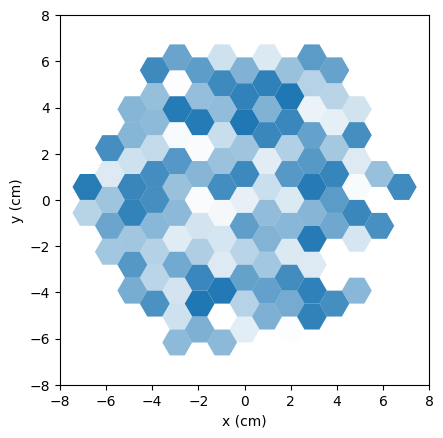

In [ ]:
sensor_density = rndw/rndw.max()

plt.clf()
fig, ax = plt.subplots(1)
fig.figsize = (6.6, 6.6)
ax.set_aspect('equal')

for ic, c in enumerate(grid):
    hexagon = RegularPolygon((c['0'], c['1']), numVertices=6, edgecolor='none',
                             radius=density/np.sqrt(3), alpha=sensor_density[ic], orientation=np.pi/6)
    ax.add_patch(hexagon)
plt.xlim([-8, 8])
plt.ylim([-8, 8])
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.savefig('xy_first_layer.png')

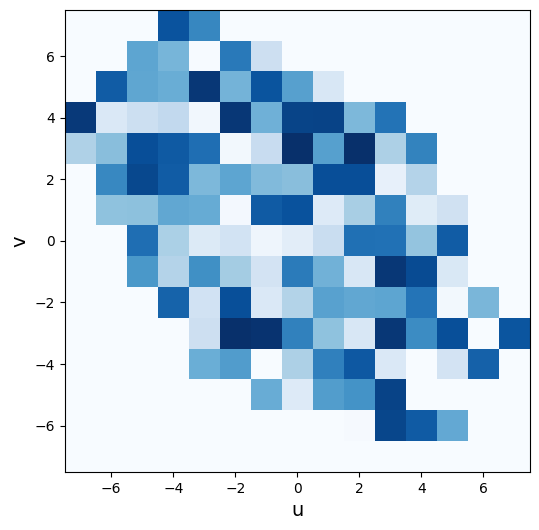

In [ ]:
#Final image used for the CNN
plt.figure(figsize=(6,6))
h_ = plt.hist2d(grid_u, grid_v, weights=rndw, bins=(15,15), range=((-7.5,7.5),(-7.5,7.5)), cmap='Blues')
plt.xlabel('u', fontsize=14)
plt.ylabel('v', fontsize=14)
plt.savefig('uv_first_layer.png')

In [ ]:
from tqdm import tqdm

#voxalization function
def voxelizza(events, zlayers, d):
    num_events = len(events)
    all_voxels = np.zeros((num_events, 28, 15, 15), dtype=np.float32)
    z_to_idx = {float(z): i for i, z in enumerate(zlayers)}

    print("voxelizzation...")
    for ev_idx in tqdm(range(num_events)):
        event = events[ev_idx]
        if len(event.x) == 0: continue

        x = ak.to_numpy(event.x)
        y = ak.to_numpy(event.y)
        z = ak.to_numpy(event.z)
        energy = ak.to_numpy(event.energy)

        u = (2 * (x / d) / np.sqrt(3))
        v = (y / d) - (x / (d * np.sqrt(3))).
        u_idx = np.clip(np.round(u + 7).astype(int), 0, 14)
        v_idx = np.clip(np.round(v + 7).astype(int), 0, 14)
        z_idx = np.array([z_to_idx[float(val)] for val in z])
        np.add.at(all_voxels[ev_idx], (z_idx, u_idx, v_idx), energy)

    return all_voxels

dataset_voxel = voxelizza(events, zlayers_coordinate, density)
drive.mount('/content/drive')


percorso_drive = '/content/drive/MyDrive/dataset_voxel5.npy'
np.save(percorso_drive, dataset_voxel)
print(f"File salvato: {percorso_drive}")

Avvio voxelizzazione...


100%|██████████| 100000/100000 [01:59<00:00, 838.38it/s]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File salvato: /content/drive/MyDrive/dataset_voxel5.npy
